# Customer Churn Prediction - Modeling Phase

This notebook focuses on training and evaluating machine learning models to predict customer churn using the cleaned dataset prepared during the exploratory data analysis phase.

In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
df = df.drop("customerID", axis=1)
x = df.drop('Churn', axis=1)
y = df['Churn']

## Feature and Target Seperation

We seperate the independent variables (features) and the dependent variable (target).

- `x` -> All input features
- `y` -> Target variable (Churn)
The target column **Churn** is removed from features and stored seperately.

In [3]:
categorical_cols = x.select_dtypes(include='object').columns
numerical_cols = x.select_dtypes(include=['int64', 'float64']).columns

## Identifying Categorical and Numerical Columns

Before encoding, we identify:

- **Categorical columns** -> Object type columns (e.g., gender, contract type)
- **Numerical columns** -> int64 and float64 columns

This helps us apply appropriate preprocessing techniques.

In [4]:
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
x_encoded = x_encoded.astype(int)

## Encoding Ctegorical Variables

We apply **One-Hot Encoding** using `pd.get_dummies()` to convert categorical features into numerical format.

- `drop_first=True` is used to avoid the dummy variable trap.
- All columns are converted to integer type for consistency.

Now, the dataset contains only numerical values and is ready for model training.

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42, stratify=y)

## Train-Test Split

The dataset is split into training and testing sets:

- 80% -> Training data
- 20% -> Testing data

We use `stratify=y` to maintain the same class distribution of churn in both training and testing sets.

This ensures balanced evaluation.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

## Feature Scaling
Numerical features are scaled using **StandardScalar**.

Why scaling?
- Some machine learning algorithms (e.g., Logistic Regression, SVM, KNN) are sensitive to feature magnitude.
- Scaling ensures all features contribute equally.

Important:
- The scaler is fitted only on training data.
- The same transformation is applied to test data.

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Training - Logistic Regression

We train Logistic Regression model for churn prediction.

Logistic Regression is suitable because:
- The target variable (Churn) is binary (0 or 1).
- It prvides probability-based predictions.
- It is interpretable and widely used as a baseline model.

In [8]:
y_pred = model.predict(x_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8045486851457001
[[918 115]
 [160 214]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Model Evaluation

The model performance is evaluated using:
- Accuracy Score
- Confusion Matrix
- Precision
- Recall
- F1-Score

Since customer churn datasets are often imbalanced,
we focus more on Recall and F1-Score rather than only Accuracy.

This helps ensure we correctly identify customers who are likely to churn.

In [10]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8361348235501189


##  ROC-AUC Score

Accuracy alone is not reliable for imbalanced datasets like customer churn.

ROC-AUC (Receiver Operating Characteristic - Area Under Curve):

- Measures how well the model distinguishes between churn and non-churn customers.
- Uses probability predictions instead of class labels.
- AUC ranges from 0 to 1.

Interpretation:
- 0.5 → Model performs like random guessing
- 0.7 - 0.8 → Good model
- 0.8 - 0.9 → Very good model
- 0.9+ → Excellent model

Higher AUC means better separability between classes.

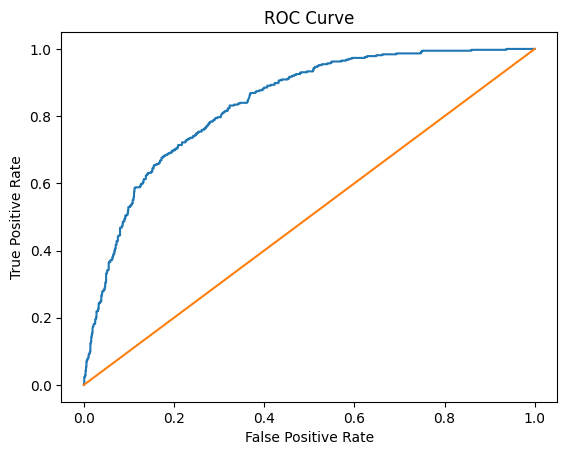

In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [12]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7036247334754797
[[827 206]
 [211 163]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1033
           1       0.44      0.44      0.44       374

    accuracy                           0.70      1407
   macro avg       0.62      0.62      0.62      1407
weighted avg       0.70      0.70      0.70      1407



In [14]:
y_prob_dt = dt_model.predict_proba(x_test)[:,1]
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.6269406380874977


In [15]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 25
Number of Leaves: 1148


##  Decision Tree Classifier

Decision Tree is a non-linear classification algorithm that splits data based on feature values.

Why use Decision Tree?

- Handles non-linear relationships
- No need for feature scaling
- Easy to interpret
- Provides feature importance

However, Decision Trees can easily overfit the data if not controlled.

In [16]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [17]:
print("Tree Depth", dt_model.get_depth())
print("ROC_AUC:", roc_auc_score(y_test, dt_model.predict_proba(x_test)[:,1]))
print("Accuracy:", accuracy_score(y_test, dt_model.predict(x_test)))
print(confusion_matrix(y_test, y_pred))

Tree Depth 5
ROC_AUC: 0.8200143913941532
Accuracy: 0.7782515991471215
[[918 115]
 [160 214]]


##  Controlling Overfitting in Decision Tree

The initial Decision Tree had a depth of 23, which indicates severe overfitting.

To improve generalization, we limit the maximum depth of the tree using `max_depth`.

This prevents the model from memorizing the training data and helps improve performance on unseen data.

In [18]:
importance = pd.Series(dt_model.feature_importances_, index=x_train.columns)
importance.sort_values(ascending=False)

tenure                                   0.448339
InternetService_Fiber optic              0.339661
TotalCharges                             0.033930
PaymentMethod_Electronic check           0.026856
OnlineSecurity_No internet service       0.026844
MonthlyCharges                           0.022792
Contract_Two year                        0.019359
StreamingMovies_No internet service      0.015440
TechSupport_Yes                          0.012189
MultipleLines_Yes                        0.010159
OnlineSecurity_Yes                       0.009306
Contract_One year                        0.009134
OnlineBackup_Yes                         0.009090
PhoneService_Yes                         0.008522
SeniorCitizen                            0.007221
PaymentMethod_Credit card (automatic)    0.001159
InternetService_No                       0.000000
Partner_Yes                              0.000000
gender_Male                              0.000000
MultipleLines_No phone service           0.000000


####  Top Important Features:

- **Tenure (44.83%)**
- **InternetService_Fiber optic (33.97%)**
- **TotalCharges (3.39%)**
- **PaymentMethod_Electronic check (2.69%)**
- **OnlineSecurity_No internet service (2.68%)**
- **MonthlyCharges (2.28%)**
- **Contract_Two year (1.94%)**

---

###  Key Insights

1. **Tenure is the most dominant factor (44.83%)**
   - Customers with lower tenure are significantly more likely to churn.
   - Retention strategies should focus on early-stage customers.

2. **Fiber optic internet customers show high churn influence (33.97%)**
   - This may indicate service dissatisfaction, pricing issues, or competitive alternatives.

3. **Billing and payment methods matter**
   - Customers using Electronic Check show higher churn probability.
   - Payment behavior may reflect engagement level or service perception.

4. **Charges-related features impact churn**
   - TotalCharges and MonthlyCharges influence customer decisions.
   - Higher billing may increase churn likelihood.

5. **Long-term contracts reduce churn**
   - Contract_Two year has notable importance.
   - Customers locked into longer contracts are less likely to churn.

---

###  Business Interpretation

The company should:

- Focus on retaining new customers (low tenure)
- Analyze churn patterns among Fiber Optic users
- Encourage long-term contracts
- Review pricing strategies for high-paying customers
- Study churn trends among Electronic Check users

In [19]:
models = {"Logistic Regression": model, "Decision Tree": dt_model}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    results.append([name, accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)])
pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"])

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.804549,0.836135
1,Decision Tree,0.778252,0.820014


##  Model Comparison

To evaluate model performance, we compared Logistic Regression and Decision Tree using Accuracy and ROC-AUC score.

Accuracy measures overall correctness, while ROC-AUC measures how well the model distinguishes between churn and non-churn customers. Since churn prediction can involve class imbalance, ROC-AUC is the more reliable metric.

---

###  Performance Results

| Model | Accuracy | ROC-AUC |
|-------|----------|----------|
| Logistic Regression | 0.8045 | 0.8361 |
| Decision Tree | 0.7783 | 0.8200 |

---

###  Interpretation

- Logistic Regression achieved higher Accuracy (80.45%) compared to Decision Tree (77.83%).
- Logistic Regression also achieved a higher ROC-AUC score (0.8361 vs 0.8200).
- This indicates that Logistic Regression is better at distinguishing between churn and non-churn customers.
- The Decision Tree model may capture non-linear patterns, but it does not outperform Logistic Regression on this dataset.

---

###  Conclusion

Based on both Accuracy and ROC-AUC, Logistic Regression performs better and generalizes more effectively on unseen data.

Therefore, Logistic Regression will be selected as the stronger baseline model for churn prediction moving forward.

In [20]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [21]:
y_pred_rf = rf_model.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(x_test)[:,1]))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7924662402274343
ROC-AUC Score: 0.8364208395670159
[[960  73]
 [219 155]]


In [23]:
models = {"Logistic Regression": model, "Decision Tree": dt_model, "Random Forest": rf_model}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    results.append([name, accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)])
pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"])

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.778252,0.820014
1,Decision Tree,0.778252,0.820014
2,Random Forest,0.792466,0.836421


##  Random Forest Evaluation

We trained a Random Forest classifier with 100 trees and a maximum depth of 5 to compare its performance with previous models.

###  Results

- Accuracy: 0.7925
- ROC-AUC: 0.8364

Confusion Matrix:

[[960, 73],  
 [219, 155]]

---

### Interpretation

- The Random Forest model achieved an **Accuracy of 79.25%** and a **ROC-AUC score of 0.836**, indicating good predictive performance.
- From the confusion matrix:
  - **960 True Negatives**: Customers correctly predicted as not churning.
  - **155 True Positives**: Customers correctly predicted as churn.
  - **73 False Positives**: Customers predicted to churn but actually did not.
  - **219 False Negatives**: Customers predicted to stay but actually churned.
- The number of false negatives suggests that some churn customers are still not being detected by the model.

---

### Conclusion

Among the tested models, **Random Forest performed the best**, achieving the highest Accuracy and ROC-AUC score.

This suggests that the ensemble approach of Random Forest helps capture patterns in the dataset better than Logistic Regression and Decision Tree.

Therefore, **Random Forest is selected as the final model for customer churn prediction.**

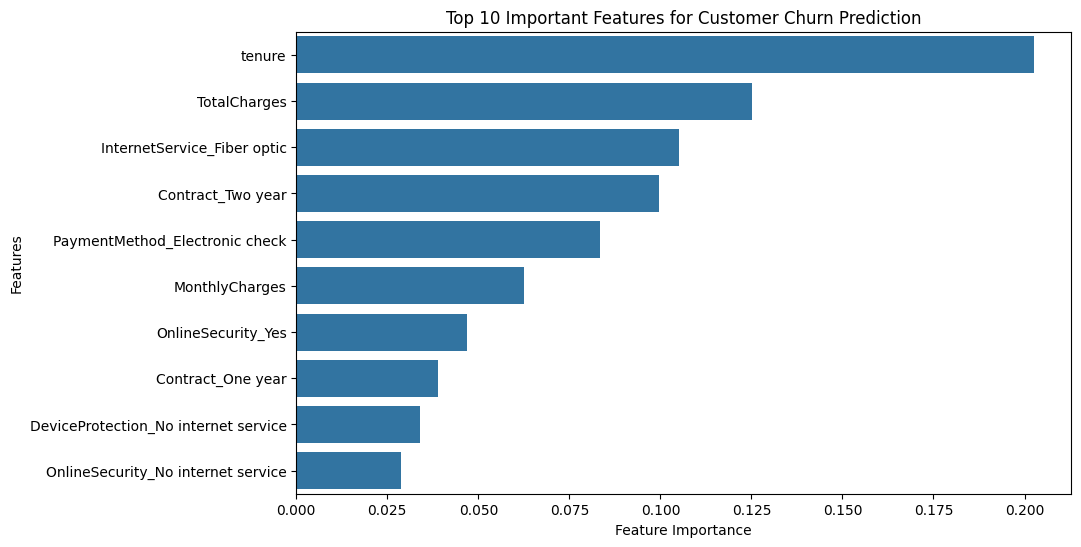

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({'Feature': x_train.columns, 'Importance': importances})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title("Top 10 Important Features for Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### Feature Importance Analysis

The Random Forest model provides feature importance scores that indicate how much each feature contributes to predicting customer churn.

From the feature importance visualization, the most influential features are:

- **Tenure** – The length of time a customer has stayed with the company. Customers with shorter tenure are more likely to churn.
- **TotalCharges** – The total amount a customer has paid to the company over time.
- **InternetService (Fiber Optic)** – Customers using fiber optic internet show a higher likelihood of churn compared to other service types.
- **Contract Type (Two Year / One Year)** – Customers with longer contracts are less likely to churn.
- **Payment Method (Electronic Check)** – Certain payment methods are associated with higher churn rates.

Other features such as **MonthlyCharges, OnlineSecurity, and DeviceProtection** also contribute to churn prediction but with relatively lower importance.

Overall, the analysis shows that **customer tenure, billing amount, service type, and contract duration are key factors influencing customer churn**.

In [27]:
import joblib
joblib.dump(rf_model, "../models/churn_model.pk1")

['../models/churn_model.pk1']

### Saving the Trained Model

After selecting the best performing model (Random Forest), the trained model is saved to disk. Saving the model allows it to be reused later for making predictions without retraining.

The model is stored as a `.pkl` file using the `joblib` library, which is commonly used for saving and loading Scikit-learn models.

In [30]:
import joblib
import pandas as pd

model = joblib.load("../models/churn_model.pk1")
sample_customer = x_test.iloc[[0]]

prediction = model.predict(sample_customer)
probability = model.predict_proba(sample_customer)[:,1]

print("Prediction:", prediction)
print("Churn Probability:", probability)

Prediction: [0]
Churn Probability: [0.06190031]


### Model Prediction Example

To demonstrate how the saved model can be used, the trained Random Forest model was loaded and applied to a sample customer from the test dataset.

**Prediction Result:**
- Prediction: **0**
- Churn Probability: **0.0619 (6.19%)**

### Interpretation

The model predicts that the selected customer **will not churn**.  
The predicted probability of churn is approximately **6.19%**, which is well below the default classification threshold of **0.5**.

This indicates that the model is relatively confident that the customer is likely to **remain with the company**.

This example demonstrates how the saved model can be reused to make churn predictions for new customers without retraining the model.

## Final Summary

In this project, a machine learning pipeline was developed to predict customer churn.

### Key Steps
- Performed Exploratory Data Analysis (EDA)
- Cleaned and preprocessed the dataset
- Encoded categorical variables and handled missing values
- Split the dataset into training and testing sets
- Trained multiple models including Logistic Regression, Decision Tree, and Random Forest
- Evaluated model performance using Accuracy and ROC-AUC
- Analyzed feature importance to understand key factors influencing churn
- Saved the best performing model for future predictions

### Final Model

The **Random Forest model** achieved the best performance:

- **Accuracy:** ~79%
- **ROC-AUC:** ~0.83

Key factors influencing churn include **Tenure, Total Charges, Internet Service type, Contract type, and Payment Method**.

The trained model was saved and demonstrated with a sample prediction, showing how it can be reused for future churn predictions.